# Feature Engineering: Encoding Substructures
Scenario: You are investigating toxicity and its dependency on molecular structure. Using the LD50 Toxicity dataset by Zhu (as provided here: https://huggingface.co/datasets/scikit-fingerprints/TDC_ld50_zhu/viewer), you calculate various molecular descriptors based on the SMILES and train a Random Forest Regressor to predict toxicity. You want to see if there is an improvement of the model when you take into account chemical structure - and generally, whether chemical structure is generally related to toxicity.

Note: the dataset is based on sparse chemical space and will not deliver super high prediction scores.

#### Tasks:
1) Load and inspect the dataset `tdc_ld50_zhu.csv`.
2) Feature engineering: Create a feature matrix `X_md` by calculating descriptors (full list as in rdkit) (Snippet provided)

3) Finding common substructures (functional groups, common scaffolds) is an alternative to detecting similarities based on fingerprints. Use the provided snippets to create different structure-based features and use one-hot encoding to make them more accessible also for other models.

4) Compare the prediction performance of the model for each of the feature matrices and combinations thereof:
- X_md: molecular descriptors only
- X_scaf: One-Hot-encoded Murcko scaffolds
- X_fg: One-hot-encoded functional groups
- X_md_scaf: Concatenation of X_md and X_scaf
- X_md_scaf_fg: Concatenation of X_md, X_scaf and X_fg

Note: For every different dataset you have to perform a train-test split and train the model before predicting. You do not need to use the suggested names!

5) Pick the best one and remove low-variance features (threshold 1%), as well as highly correlated ones (threshold 90%). See if the performance of the predictions by the model improves. Hint: Use `VarianceThreshold` (Unsupervised Algorithm from Scikit-learn) and `corr_matrix = X.corr().abs()` to do so (e.g. similarly as used in the Clustering example on the ESOL dataset)

6) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.

7) Use Butina clustering on UMAP visualisation of the smiles-fingerprint space (scatterplot) and compare the plot side by side (e.g. as suplots) with a scatterplot colourmapped to the toxicity (look at options such as `colorbar` for matplotlib for better visualisation). 

8) Repeat 6 and 7 for the fingerprints based on the Murcko Scaffolds from task 3

9) Respond to the discussion points


Import dependencies and datasets

In [1]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MolFromSmarts
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder

from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit.ML.Cluster import Butina

1) Load and investigate the data

In [2]:
tox = pd.read_csv("tdc_ld50_zhu.csv")
tox.head()

,smiles,ld_50
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505
1,BrC(Br)Br,2.343
2,C=CBr,2.330
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
4,S=C=Nc1ccc(Br)cc1,2.729


2) Calculate descriptors

In [3]:
descriptor_names = [d[0] for d in Descriptors._descList]

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [desc[1](mol) for desc in Descriptors._descList]

X_md = tox.smiles.apply(calc_descriptors)

X_md = pd.DataFrame(X_md.tolist(), columns=descriptor_names)
X_md = X_md.dropna()

y = tox["ld_50"]

3) Find common scaffolds and encode them as binary vecotrs (one-hot-encoding). Note that the Scaffolds are represented as SMILES and can be used for fingerprints later

In [4]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

tox["scaffold"] = tox["smiles"].apply(get_scaffold).astype(str)

OneHotEncoder for the Murcko scaffolds:

In [13]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

scaffold_ohe = encoder.fit_transform(
    tox[["scaffold"]]
)

scaffold_cols = encoder.get_feature_names_out(["scaffold"])

X_scaf = pd.DataFrame(
    scaffold_ohe,
    columns=scaffold_cols,
    index=tox.index
)

Instead of structural scaffolds (via SMARTS), encode functional groups using the one-hot-encoder. Add some more functional groups that you think have impact on the toxicity of compounds.

In [14]:
functional_groups = {
    "alcohol": "[OX2H]",
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carboxylic_acid": "C(=O)[OX2H1]",
    "halogen": "[F,Cl,Br,I]",
    "aromatic_ring": "a"
}

In [15]:
patterns = {k: Chem.MolFromSmarts(v) for k,v in functional_groups.items()}

def detect_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {
        name: int(mol.HasSubstructMatch(pat))
        for name, pat in patterns.items()
    }

X_fg = pd.DataFrame(
    tox["smiles"].apply(detect_groups).tolist()
)

One-hot encoder for functional groups

In [16]:
# not needed, functional groups already present as binaries


4. Train and evaluate the model

In [21]:
# build dataframes
X_md_scaf = pd.concat(
    [X_md, X_scaf],
    axis=1
)

X_md_fg = pd.concat(
    [X_md, X_fg],
    axis=1
)

X_md_scaf_fg = pd.concat(
    [X_md_scaf, X_fg],
    axis=1
)

# define dataframe list:
X_dict = {
    "X_md": X_md, 
    "X_scaf": X_scaf, 
    "X_fg": X_fg, 
    "X_md_fg": X_md_fg, 
    "X_md_scaf": X_md_scaf, 
    "X_md_scaf_fg": X_md_scaf_fg
    }   

In [22]:
# define model:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [25]:
for name, df in X_dict.items():
    X_train, X_test, y_train, y_test = train_test_split(
        df,
        y,
        test_size=0.2,
        random_state=42
    )

    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    print(f"R2 score - {name}: ", r2_score(y_test, pred))

R2 score - X_md:  0.6205967774886036
R2 score - X_scaf:  0.20706907995438062
R2 score - X_fg:  0.06768136924301982
R2 score - X_md_fg:  0.6224311537154035
R2 score - X_md_scaf:  0.6128923097382516
R2 score - X_md_scaf_fg:  0.614461288490016


5) Pick the best one and prune the features regarding variance and correlation. Run the regression model again and compare the performance.

In [27]:
from sklearn.feature_selection import VarianceThreshold
print("Before variance filter:", X_md_fg.shape)

var_filter = VarianceThreshold(threshold=0.01)
X_var = var_filter.fit_transform(X_md_fg)

X_md_fg = pd.DataFrame(X_var, columns=X_md_fg.columns[var_filter.get_support()])
print("After variance filter:", X_md_fg.shape)

Before variance filter: (7376, 197)
After variance filter: (7376, 197)


In [28]:
print("Before correlation filtering:", X_md_fg.shape)
corr_matrix = X_md_fg.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_md_fg = X_md_fg.drop(columns=to_drop)

print("After correlation filtering:", X_md_fg.shape)

Before correlation filtering: (7376, 197)
After correlation filtering: (7376, 154)


6) Generate Morgan fingerprints (2048 bit, radius=2) for both "smiles" (entire molecules) and "scaffolds" (SMILES of common scaffolds only)

In [29]:
def morgan_fp(mols):
    fpg = rdFingerprintGenerator.GetMorganGenerator(fpSize=2048, radius=2)
    fp = fpg.GetFingerprint(mols)
    return fp

# Fingerprints on scaffold
mols_scaf = [Chem.MolFromSmiles(s) for s in tox["scaffold"]]
mols_scaf = [m for m in mols_scaf if m is not None]

fps_scaf = [morgan_fp(m) for m in mols_scaf]
fps_scaf = [fp for fp in fps_scaf if fp is not None]

# Fingerprints on smiles
mols_smiles = [Chem.MolFromSmiles(s) for s in tox["scaffold"]]
mols_smiles = [m for m in mols_smiles if m is not None]

fps_smiles = [morgan_fp(m) for m in mols_smiles]
smiles = [fp for fp in fps_smiles if fp is not None]

7) Butina clustering (as in last exercise): Experiment with different cutoffs and filter limits for the clusters (compare in the visualisation, no need to rerun the UMAP visualisation in between)

In [30]:
# Scaffold clustering

dists = []
nfps = len(fps_scaf)
cutoff = 0.6

for i in range(1, nfps):
    sims = DataStructs.BulkTanimotoSimilarity(fps_scaf[i], fps_scaf[:i])
    dists.extend([1-x for x in sims])

clusters_scaf = Butina.ClusterData(
    dists,
    nfps,
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(clusters_scaf))

Number of clusters: 747


In [31]:
# Smiles clustering

dists = []
nfps = len(fps_smiles)
cutoff = 0.6

for i in range(1, nfps):
    sims = DataStructs.BulkTanimotoSimilarity(fps_smiles[i], fps_smiles[:i])
    dists.extend([1-x for x in sims])

clusters_smiles = Butina.ClusterData(
    dists,
    nfps,
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(clusters_smiles))

Number of clusters: 747


In [32]:
# filter out small clusters, rare chemoptypes, ... for smiles
clusters_filtered_smiles = [c for c in clusters_smiles if len(c) >= 15]

butina_labels_smiles = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered_smiles):
    for id in cluster:
        butina_labels_smiles[id] = cluster_id

sizes = [len(c) for c in clusters_filtered_smiles]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 57
mean size: 99.64912280701755
max size: 1936
singletons: 0


In [33]:
# filter out small clusters, rare chemoptypes, ... for scaffolds
clusters_filtered_scaf = [c for c in clusters_scaf if len(c) >= 15]

butina_labels_scaf = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered_scaf):
    for id in cluster:
        butina_labels_scaf[id] = cluster_id

sizes = [len(c) for c in clusters_filtered_scaf]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 57
mean size: 99.64912280701755
max size: 1936
singletons: 0


Calculate UMAP space - play with `n_neighbors` and `min_distance` until you are satisfied with the visualisation.

In [34]:
# convert fingerprints to numpy for scaffolds
fp_array_scaf = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fps_scaf):
    DataStructs.ConvertToNumpyArray(fp, fp_array_scaf[i])

In [46]:
reducer_scaf = umap.UMAP(
    n_neighbors=20,
    min_dist=1,
    random_state=42
)

umap_emb_scaf = reducer_scaf.fit_transform(fp_array_scaf)

c:\Users\jschoer\Desktop\DSA104development\DSA104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [36]:
# convert fingerprints to numpy for smiles
fp_array_smiles = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fps_smiles):
    DataStructs.ConvertToNumpyArray(fp, fp_array_smiles[i])

In [45]:
reducer_smiles = umap.UMAP(
    n_neighbors=15,
    min_dist=1,
    random_state=42
)

umap_emb_smiles = reducer_smiles.fit_transform(fp_array_smiles)

c:\Users\jschoer\Desktop\DSA104development\DSA104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\jschoer\Desktop\DSA104development\DSA104\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Visualise the UMAP space with the a) the cluster labels and b) the toxicity as colour hue. (Incomplete snippet for matplotlib provided - feel free to use whatever visualisation that works best for you)

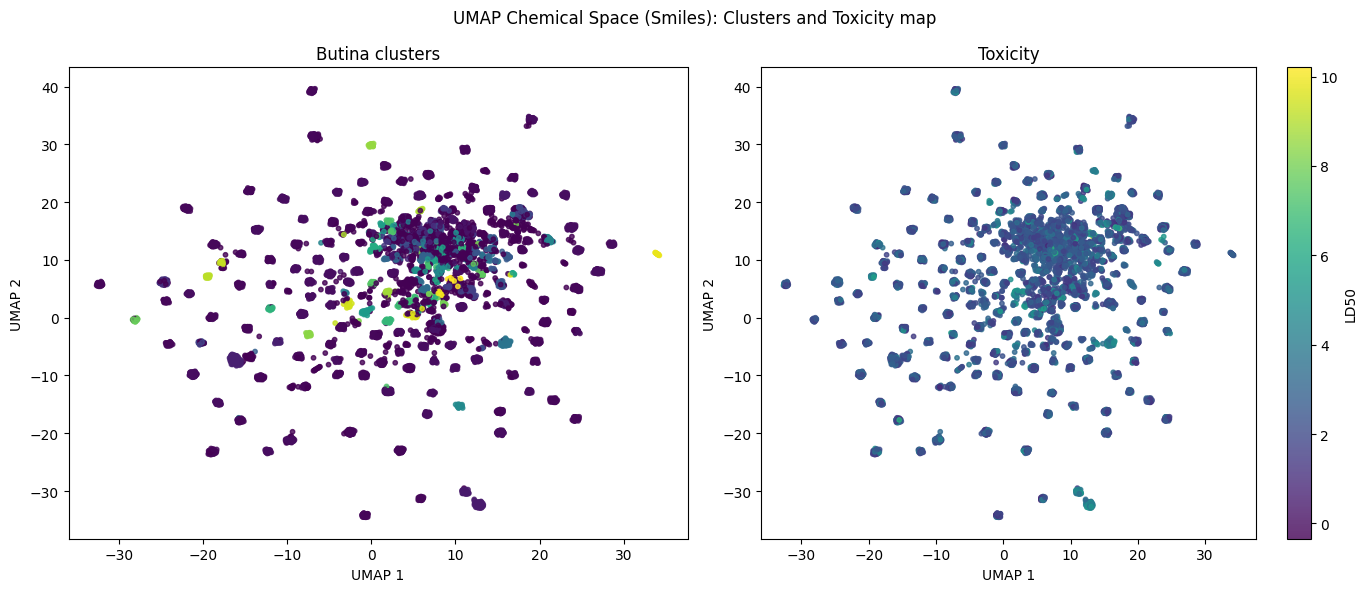

In [47]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,6))
fig.suptitle("UMAP Chemical Space (Smiles): Clusters and Toxicity map")

# ax1 = Chemical space and butina clustering
ax1.scatter(
    umap_emb_smiles[:,0],
    umap_emb_smiles[:,1],
    c=butina_labels_smiles,
    cmap="viridis",
    s=10,
    alpha=0.8
)
ax1.set(xlabel ="UMAP 1", ylabel="UMAP 2")
ax1.set_title("Butina clusters")

# ax2 toxicity map
toxmap = ax2.scatter(
    umap_emb_smiles[:,0],
    umap_emb_smiles[:,1],
    c=y,
    cmap="viridis",
    s=10,
    alpha=0.8
)

fig.colorbar(toxmap, label="LD50",ax=ax2)

ax2.set(xlabel ="UMAP 1", ylabel="UMAP 2")
ax2.set_title("Toxicity")

plt.tight_layout()
plt.show()


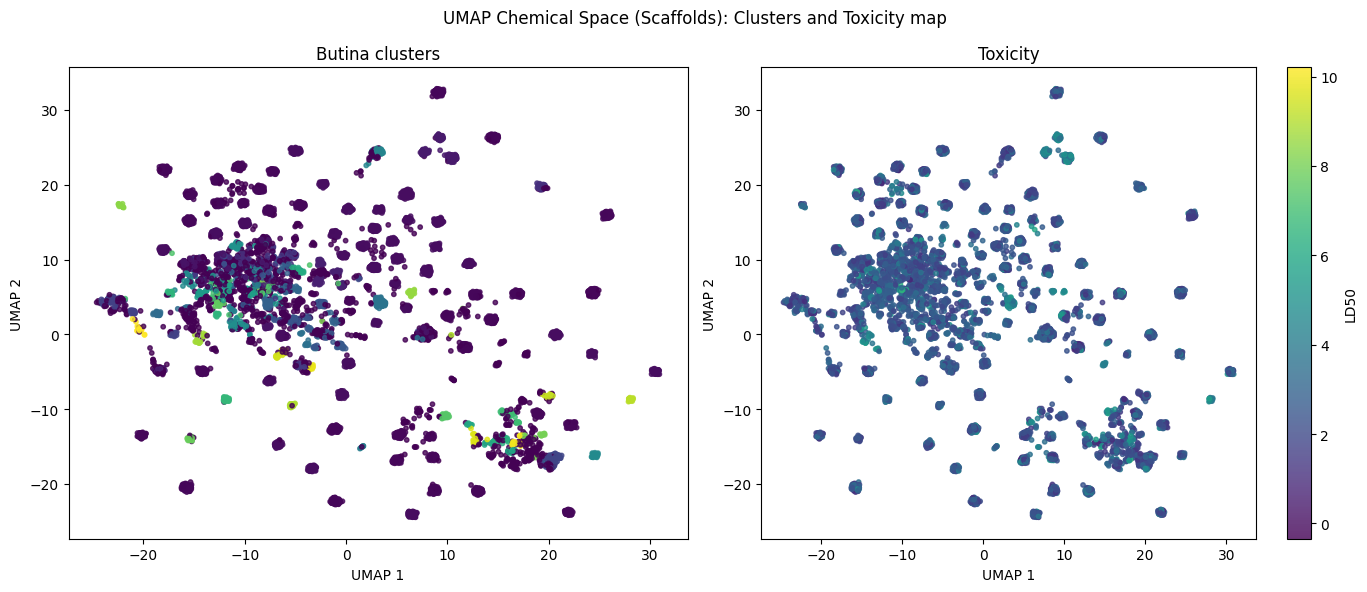

In [48]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,6))
fig.suptitle("UMAP Chemical Space (Scaffolds): Clusters and Toxicity map")

# ax1 = Chemical space and butina clustering
ax1.scatter(
    umap_emb_scaf[:,0],
    umap_emb_scaf[:,1],
    c=butina_labels_scaf,
    cmap="viridis",
    s=10,
    alpha=0.8
)
ax1.set(xlabel ="UMAP 1", ylabel="UMAP 2")
ax1.set_title("Butina clusters")

# ax2 toxicity map
toxmap = ax2.scatter(
    umap_emb_scaf[:,0],
    umap_emb_scaf[:,1],
    c=y,
    cmap="viridis",
    s=10,
    alpha=0.8
)

fig.colorbar(toxmap, label="LD50",ax=ax2)

ax2.set(xlabel ="UMAP 1", ylabel="UMAP 2")
ax2.set_title("Toxicity")

plt.tight_layout()
plt.show()


#### 9) Discussion points
1) How did the scaffolds and functional groups perform in the model performance in comparison the molecular descriptors? Comment on possible reasons. Which combination was suited best?
2) Is the One-Hot Encoding needed in this case?
3) Did the feature filtering (variance, correlation) have an improving effect? Explain!
4) Consider to make this kind of workflow for feature comparison more generally usable: How would a clean solution look? How could you ensure compatibility with other models? How would the function / pipeline look schematically?
5) Visualisation: Using the scaffold fingerprints and the fingerprints for the entire molecule makes a huge difference. What is reason for this effect? Discuss this approach in contrast to similarity thresholds in the Butina clustering.
6) When might scaffolding prove useful?
7) Is toxicity correlated to molecular structure? I.e. what did the toxicity map in UMAP space reveal?
